# Treino ESRGAN (Enhanced Super-Resolution Generative Adversarial Networks)

**Referência:** Wang et al., 2018 - "ESRGAN: Enhanced Super-Resolution Generative Adversarial Networks"

Este notebook contém o treino do modelo ESRGAN com duas fases:
1. **Warm-up (PSNR)**: Treino com L1 Loss para aprender formas básicas
2. **GAN**: Treino adversarial com Loss Perceptual e Adversarial

Para análise exploratória dos dados e comparação com outros modelos, veja `00_guia_analise_comparacao.ipynb`.

## Setup e Configurações

In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import models

sys.path.append(".")

from datasets import SRDataset, SRBenchmarkDataset, SREvalDataset
from metrics import calc_psnr, calc_ssim
from train import evaluate

/home/al.gabriel.vieira/Downloads/ml2/upscaling-ml/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configurar seeds para reprodutibilidade
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed fixada: {SEED}")

Seed fixada: 42


In [3]:
# Detectar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}")

Dispositivo: cuda
Torch: 2.11.0+cu128


In [4]:
# Criar diretório de outputs
student_tag = "ESRGAN_2026-07-05"  # Altere conforme necessário
output_dir = Path("outputs") / student_tag
output_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(output_dir / "tensorboard"))

print(f"Output dir: {output_dir}")

Output dir: outputs/ESRGAN_2026-07-05


## Definição dos Modelos

In [5]:
# Blocos de construção do ESRGAN

class ResidualDenseBlock_5C(nn.Module):
    """Residual Dense Block com 5 camadas convolutivas (como no ESRGAN)"""
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    """Residual Residual Dense Block"""
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.RDB1 = ResidualDenseBlock_5C(nf, gc)
        self.RDB2 = ResidualDenseBlock_5C(nf, gc)
        self.RDB3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        return (self.RDB3(self.RDB2(self.RDB1(x)))) * 0.2 + x

class ESRGANGenerator(nn.Module):
    """Gerador ESRGAN com 23 blocos RRDB"""
    def __init__(self, in_nc=3, out_nc=3, nf=64, nb=23, gc=32, scale=4):
        super().__init__()
        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1)
        self.RRDB_trunk = nn.Sequential(*[RRDB(nf, gc) for _ in range(nb)])
        self.conv_body = nn.Conv2d(nf, nf, 3, 1, 1)
        self.upconv1 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.upconv2 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.HRconv = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.conv_body(self.RRDB_trunk(fea))
        fea = fea + trunk
        fea = self.lrelu(self.upconv1(F.interpolate(fea, scale_factor=2, mode='nearest')))
        fea = self.lrelu(self.upconv2(F.interpolate(fea, scale_factor=2, mode='nearest')))
        return self.conv_last(self.lrelu(self.HRconv(fea)))

print("Modelos definidos")

Modelos definidos


In [6]:
class VGGDiscriminator(nn.Module):
    """Discriminador com arquitetura VGG"""
    def __init__(self, in_nc=3, nf=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_nc, nf, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf, 3, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf * 2, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 2, nf * 2, 3, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 2, nf * 4, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 4, nf * 4, 3, 2, 1), nn.LeakyReLU(0.2, True)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(nf * 4, 256), nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1)
        )
        
    def forward(self, x):
        return self.classifier(self.features(x))

class VGGFeatureExtractor(nn.Module):
    """Extrator de features perceptual usando VGG19 pré-treinado"""
    def __init__(self):
        super().__init__()
        vgg19 = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.features = nn.Sequential(*list(vgg19.features.children())[:35]).eval()
        for param in self.features.parameters(): 
            param.requires_grad = False
            
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.features(x)

print("Discriminador e Feature Extractor definidos")

Discriminador e Feature Extractor definidos


## Carregamento de Dados

In [7]:
# Configurações de dataset
PATCH_SIZE = 192
SCALE = 4
BATCH_SIZE = 8

# Carregar datasets
train_dataset = SRDataset("datasets/DF2K_train_HR", patch_size=PATCH_SIZE, scale=SCALE)

try:
    val_dataset = SRBenchmarkDataset("datasets/Set5/image_SRF_4", scale=SCALE)
except FileNotFoundError:
    print("Benchmark Set5 não encontrado. Usando validação com DIV2K_valid.")
    val_dataset = SREvalDataset("datasets/DF2K_valid_HR", scale=SCALE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

print(f"Dataset de treino: {len(train_dataset)} patches")
print(f"Dataset de validação: {len(val_dataset)} imagens")
print(f"Batch size: {BATCH_SIZE} | Patch size: {PATCH_SIZE}x{PATCH_SIZE} | Scale: {SCALE}x")

Benchmark Set5 não encontrado. Usando validação com DIV2K_valid.
Dataset de treino: 3450 patches
Dataset de validação: 100 imagens
Batch size: 8 | Patch size: 192x192 | Scale: 4x


## Funções de Treinamento

In [8]:
def train_warmup(netG, dataloader, optimizer_G, criterion_L1, device):
    """Fase 1: Pré-treino apenas com L1 para ensinar a rede a desenhar a imagem básica"""
    netG.train()
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc="Warm-up (Apenas L1)", leave=False)
    
    for lr_img, hr_img in pbar:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        
        optimizer_G.zero_grad()
        fake_hr = netG(lr_img)
        loss = criterion_L1(fake_hr, hr_img)
        loss.backward()
        optimizer_G.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss_L1": f"{loss.item():.4f}"})
        
    return epoch_loss / len(dataloader)

print("Função de warm-up definida")

Função de warm-up definida


In [9]:
def train_one_epoch_gan(netG, netD, loader, opt_G, opt_D, crit_L1, crit_BCE, ext_vgg, device):
    """Fase 2: Treinamento Adversarial completo"""
    netG.train()
    netD.train()
    epoch_g_loss = 0.0
    
    pbar = tqdm(loader, desc="Treinando ESRGAN GAN", leave=False)
    for lr_img, hr_img in pbar:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        
        # Treino Discriminador
        opt_D.zero_grad()
        fake_hr = netG(lr_img)
        pred_real, pred_fake = netD(hr_img), netD(fake_hr.detach())
        loss_D_real = crit_BCE(pred_real - torch.mean(pred_fake), torch.ones_like(pred_real))
        loss_D_fake = crit_BCE(pred_fake - torch.mean(pred_real), torch.zeros_like(pred_fake))
        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        opt_D.step()
        
        # Treino Gerador
        opt_G.zero_grad()
        pred_real, pred_fake = netD(hr_img.detach()), netD(fake_hr)
        
        loss_content = crit_L1(fake_hr, hr_img)
        loss_perceptual = crit_L1(ext_vgg(fake_hr), ext_vgg(hr_img))
        loss_G_adv_real = crit_BCE(pred_real - torch.mean(pred_fake), torch.zeros_like(pred_real))
        loss_G_adv_fake = crit_BCE(pred_fake - torch.mean(pred_real), torch.ones_like(pred_fake))
        loss_G_adv = (loss_G_adv_real + loss_G_adv_fake) / 2
        
        loss_G = (1e-2 * loss_content) + (1.0 * loss_perceptual) + (5e-3 * loss_G_adv)
        loss_G.backward()
        opt_G.step()
        
        epoch_g_loss += loss_G.item()
        pbar.set_postfix({"Loss_G": f"{loss_G.item():.4f}", "Loss_D": f"{loss_D.item():.4f}"})
        
    return epoch_g_loss / len(loader)

print("Função de treino GAN definida")

Função de treino GAN definida


## Treino do ESRGAN

In [10]:
# Inicializar modelos
netG = ESRGANGenerator(scale=4).to(device)
netD = VGGDiscriminator().to(device)
ext_vgg = VGGFeatureExtractor().to(device)

# Otimizadores
opt_G = torch.optim.Adam(netG.parameters(), lr=1e-4, betas=(0.9, 0.999))
opt_D = torch.optim.Adam(netD.parameters(), lr=1e-4, betas=(0.9, 0.999))

# Critérios
crit_L1 = nn.L1Loss()
crit_BCE = nn.BCEWithLogitsLoss()

print(f"Gerador ESRGAN parâmetros: {sum(p.numel() for p in netG.parameters()):,}")
print(f"Discriminador parâmetros: {sum(p.numel() for p in netD.parameters()):,}")

Gerador ESRGAN parâmetros: 16,697,987
Discriminador parâmetros: 320,289


In [11]:
# Configurações de treino
EPOCHS = 100
WARMUP_EPOCHS = 20

print(f"\nIniciando treino ESRGAN...")
print(f"  Warm-up: {WARMUP_EPOCHS} epochs")
print(f"  GAN: {EPOCHS - WARMUP_EPOCHS} epochs")
print(f"  Total: {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    if epoch < WARMUP_EPOCHS:
        # Fase de Estabilização
        loss = train_warmup(netG, train_loader, opt_G, crit_L1, device)
        fase = "Warm-up"
        
        if (epoch + 1) == WARMUP_EPOCHS:
            torch.save(netG.state_dict(), output_dir / "esrgan_generator_warmup.pth")
            print(f"[CHECKPOINT] Pesos de Warm-up salvos\n")
            
    else:
        # Fase GAN
        loss = train_one_epoch_gan(netG, netD, train_loader, opt_G, opt_D, crit_L1, crit_BCE, ext_vgg, device)
        fase = "GAN"
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} [{fase:7s}] — Loss: {loss:.6f}")
    
    if (epoch + 1) % 50 == 0 and epoch >= WARMUP_EPOCHS:
        val_metrics = evaluate(netG, val_loader, device, scale=4, upscale_input=False)
        print(f"   [Validação] PSNR: {val_metrics['psnr_model']:.2f} dB | SSIM: {val_metrics['ssim_model']:.4f}")

print("\nTreino concluído!")


Iniciando treino ESRGAN...
  Warm-up: 20 epochs
  GAN: 80 epochs
  Total: 100 epochs



Epoch  10/100 [Warm-up] — Loss: 0.033918


[CHECKPOINT] Pesos de Warm-up salvos

Epoch  20/100 [Warm-up] — Loss: 0.030497


Epoch  30/100 [GAN    ] — Loss: 1.222702


Epoch  40/100 [GAN    ] — Loss: 1.199585


...

Epoch  70/100 [GAN    ] — Loss: 1.154843


Epoch  80/100 [GAN    ] — Loss: 1.142435


Epoch  90/100 [GAN    ] — Loss: 1.138541


Epoch 100/100 [GAN    ] — Loss: 1.135865


   [Validação] PSNR: 26.03 dB | SSIM: 0.9658

Treino concluído!


## Salvamento e Interpolação de Modelos

In [12]:
# Salvar modelos
torch.save(netG.state_dict(), output_dir / "esrgan_generator_gan.pth")
torch.save(netD.state_dict(), output_dir / "esrgan_discriminator.pth")

print("Modelos salvos:")
print(f"  - {output_dir / 'esrgan_generator_warmup.pth'}")
print(f"  - {output_dir / 'esrgan_generator_gan.pth'}")
print(f"  - {output_dir / 'esrgan_discriminator.pth'}")

Modelos salvos:
  - outputs/ESRGAN_2026-07-05/esrgan_generator_warmup.pth
  - outputs/ESRGAN_2026-07-05/esrgan_generator_gan.pth
  - outputs/ESRGAN_2026-07-05/esrgan_discriminator.pth


In [13]:
# Interpolação de modelos (PSNR vs Qualidade Perceptual)
netG_PSNR = ESRGANGenerator(scale=4).to(device)
netG_PSNR.load_state_dict(torch.load(output_dir / "esrgan_generator_warmup.pth"))

netG_GAN = ESRGANGenerator(scale=4).to(device)
netG_GAN.load_state_dict(torch.load(output_dir / "esrgan_generator_gan.pth"))

netG_interp = ESRGANGenerator(scale=4).to(device)
alpha = 0.8  # 80% GAN, 20% PSNR (recomendado pelo artigo)

state_dict_PSNR = netG_PSNR.state_dict()
state_dict_GAN = netG_GAN.state_dict()
state_dict_interp = netG_interp.state_dict()

for key in state_dict_interp.keys():
    state_dict_interp[key] = (1 - alpha) * state_dict_PSNR[key] + alpha * state_dict_GAN[key]

netG_interp.load_state_dict(state_dict_interp)
torch.save(netG_interp.state_dict(), output_dir / "esrgan_final_interpolated.pth")

print(f"Modelo interpolado salvo (alpha={alpha}):")
print(f"  - {output_dir / 'esrgan_final_interpolated.pth'}")

Modelo interpolado salvo (alpha=0.8):
  - outputs/ESRGAN_2026-07-05/esrgan_final_interpolated.pth


## Avaliação dos Resultados

In [14]:
# Avaliar as 3 variantes
print("Avaliando modelos...\n")

netG_PSNR.eval()
netG_GAN.eval()
netG_interp.eval()

models_to_eval = {
    "ESRGAN (PSNR - Warm-up)": netG_PSNR,
    "ESRGAN (GAN)": netG_GAN,
    "ESRGAN (Interpolado 80% GAN)": netG_interp
}

for name, model in models_to_eval.items():
    metrics = evaluate(model, val_loader, device, scale=4, upscale_input=False)
    print(f"{name}:")
    print(f"  PSNR: {metrics['psnr_model']:.2f} dB")
    print(f"  SSIM: {metrics['ssim_model']:.4f}")
    print()

Avaliando modelos...



ESRGAN (PSNR - Warm-up):
  PSNR: 27.77 dB
  SSIM: 0.9759



ESRGAN (GAN):
  PSNR: 26.03 dB
  SSIM: 0.9658



ESRGAN (Interpolado 80% GAN):
  PSNR: 23.47 dB
  SSIM: 0.9575



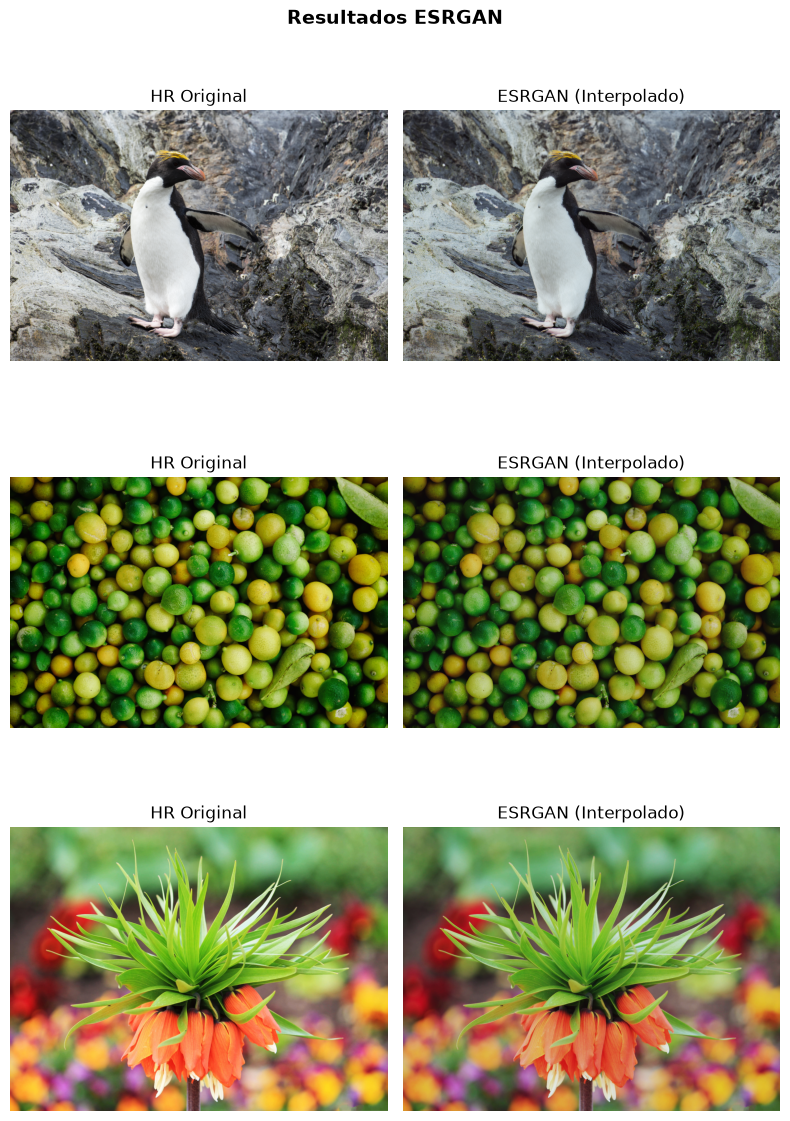

Imagem salva em: outputs/ESRGAN_2026-07-05/resultados_esrgan.png


In [15]:
# Visualizar resultados
def tensor_to_img(t):
    return t.detach().squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

n_samples = 3
fig, axes = plt.subplots(n_samples, 2, figsize=(8, 4 * n_samples))

with torch.no_grad():
    for i, (lr_img, hr_img) in enumerate(val_loader):
        if i >= n_samples:
            break
        
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        sr_esrgan = netG_interp(lr_img).clamp(0, 1)
        
        axes[i, 0].imshow(tensor_to_img(hr_img))
        axes[i, 0].set_title("HR Original")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(tensor_to_img(sr_esrgan))
        axes[i, 1].set_title("ESRGAN (Interpolado)")
        axes[i, 1].axis("off")

plt.suptitle("Resultados ESRGAN", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir / "resultados_esrgan.png", dpi=150)
plt.show()

print(f"Imagem salva em: {output_dir / 'resultados_esrgan.png'}")